# Lab 21 - GNNs

In [3]:
import torch
import torch.nn as nn
import torch_geometric.nn as gnn
import numpy as np
import math
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Ex. 1) GCNConv vs GraphConv vs GraphSAGE

📘 **Cora Dataset — Overview**

The Cora dataset is one of the most widely used citation networks for evaluating graph neural networks (GNNs), especially for semi-supervised node classification.

It consists of:
-	**Nodes**: scientific publications
-	**Edges**: citation links between publications
-	**Node** **features**: bag-of-words vectors
-	**Node labels**: research topic of the publication

🎯 **Task: Semi-Supervised Node Classification**

Cora is used for transductive learning:
-	You are given the entire graph structure
-	Only a small subset of nodes (140) have labels
-	The goal is to infer the labels of the remaining 2,568 unlabeled nodes

This setup matches real-world problems like classifying users in a social network where only some accounts are labeled.


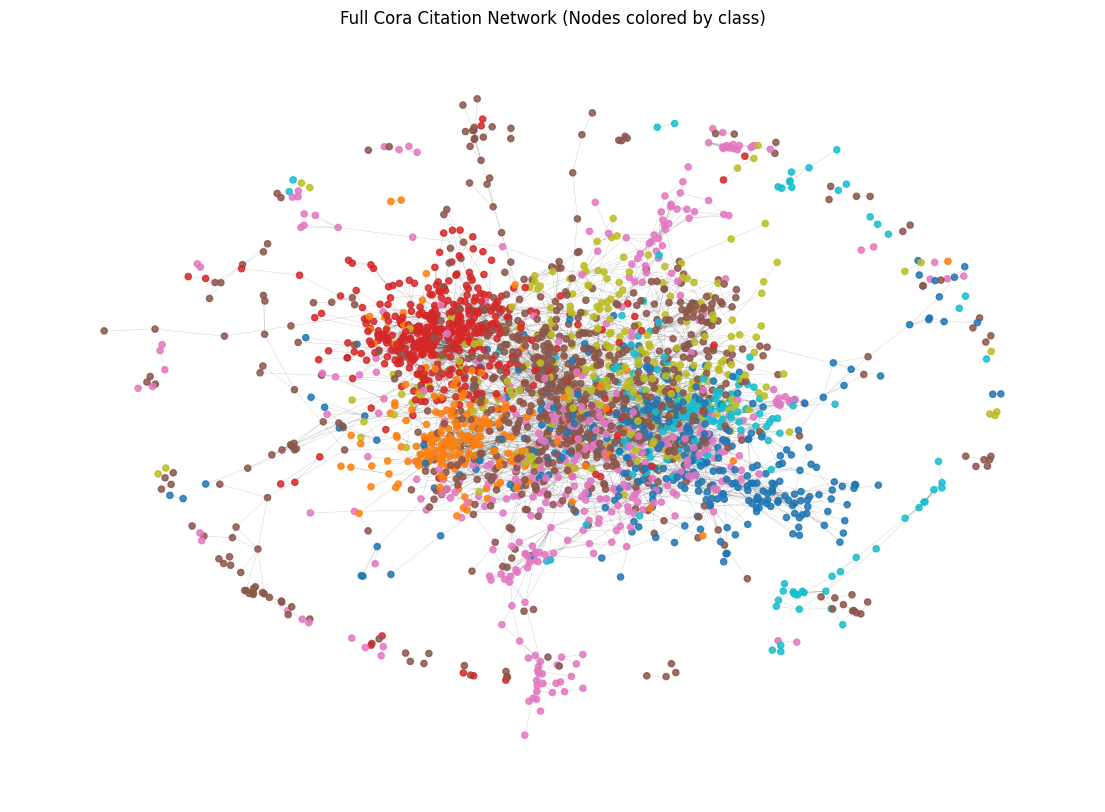

In [ ]:
from torch_geometric.utils import to_networkx

dataset = Planetoid(root="data/Cora", name="Cora")
data = dataset[0]

# Convert to NetworkX graph
G = to_networkx(data, to_undirected=True)

labels = data.y.numpy()
node_colors = [labels[i] for i in range(data.num_nodes)]

pos = nx.spring_layout(G, seed=42, k=3 / math.sqrt(data.num_nodes))

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(
    G, pos, node_size=20, node_color=node_colors, cmap=plt.cm.tab10, alpha=0.85
)
nx.draw_networkx_edges(G, pos, width=0.3, alpha=0.2)

plt.title("Full Cora Citation Network (Nodes colored by class)")
plt.axis("off")
plt.show()

In [16]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [16]:
class GCNModel(nn.Module):
    
    def __init__(self, n_input, n_hidden, n_output):
        super().__init__()
        self.conv1 = gnn.GCNConv(n_input, n_hidden)
        self.conv2 = gnn.GCNConv(n_hidden, n_output)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = nn.functional.relu(x)
        x = self.conv2(x, edge_index)
        return x
    
def get_acc(data, mask, out):
    preds = out.argmax(dim=1)
    correct = (preds[mask] == data.y[mask]).sum().item()
    return correct / mask.sum()

dataset = Planetoid(root="data/Cora", name="Cora")
data = dataset[0].to(device)
model = GCNModel(dataset.num_features, 16, dataset.num_classes).to(device)

EPOCHS = 200
LR = 0.03
WEIGHT_DECAY = 5e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_function = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    out = model(data)

    train_loss = loss_function(out[data.train_mask], data.y[data.train_mask]) 
    train_loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        val_loss = loss_function(out[data.val_mask], data.y[data.val_mask]) 
        test_loss = loss_function(out[data.test_mask], data.y[data.test_mask]) 
        
        train_acc = get_acc(data, data.train_mask, out)
        val_acc = get_acc(data, data.val_mask, out)
        test_acc = get_acc(data, data.test_mask, out)
    

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Test Acc: {test_acc:.3f}")
        

Epoch    0 | Train Loss: 1.957 | Train Acc: 0.143 | Val Acc: 0.220 | Test Acc: 0.220
Epoch   50 | Train Loss: 0.066 | Train Acc: 1.000 | Val Acc: 0.776 | Test Acc: 0.810
Epoch  100 | Train Loss: 0.067 | Train Acc: 1.000 | Val Acc: 0.776 | Test Acc: 0.808
Epoch  150 | Train Loss: 0.067 | Train Acc: 1.000 | Val Acc: 0.778 | Test Acc: 0.812
Epoch  199 | Train Loss: 0.067 | Train Acc: 1.000 | Val Acc: 0.778 | Test Acc: 0.810


In [19]:
class GraphConvModel(nn.Module):
    
    def __init__(self, n_input, n_hidden, n_output):
        super().__init__()
        self.conv1 = gnn.GraphConv(n_input, n_hidden, aggr="add")
        self.conv2 = gnn.GraphConv(n_hidden, n_output, aggr="add")

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = nn.functional.relu(x)
        x = self.conv2(x, edge_index)
        return x
    
def get_acc(data, mask, out):
    preds = out.argmax(dim=1)
    correct = (preds[mask] == data.y[mask]).sum().item()
    return correct / mask.sum()

dataset = Planetoid(root="data/Cora", name="Cora")
data = dataset[0].to(device)
model = GCNModel(dataset.num_features, 16, dataset.num_classes).to(device)

EPOCHS = 200
LR = 0.03
WEIGHT_DECAY = 5e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_function = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    out = model(data)

    train_loss = loss_function(out[data.train_mask], data.y[data.train_mask]) 
    train_loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        val_loss = loss_function(out[data.val_mask], data.y[data.val_mask]) 
        test_loss = loss_function(out[data.test_mask], data.y[data.test_mask]) 
        
        train_acc = get_acc(data, data.train_mask, out)
        val_acc = get_acc(data, data.val_mask, out)
        test_acc = get_acc(data, data.test_mask, out)
    

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Test Acc: {test_acc:.3f}")
        

Epoch    0 | Train Loss: 1.939 | Train Acc: 0.164 | Val Acc: 0.146 | Test Acc: 0.134
Epoch   50 | Train Loss: 0.065 | Train Acc: 1.000 | Val Acc: 0.776 | Test Acc: 0.810
Epoch  100 | Train Loss: 0.067 | Train Acc: 1.000 | Val Acc: 0.778 | Test Acc: 0.812
Epoch  150 | Train Loss: 0.067 | Train Acc: 1.000 | Val Acc: 0.782 | Test Acc: 0.809
Epoch  199 | Train Loss: 0.067 | Train Acc: 1.000 | Val Acc: 0.784 | Test Acc: 0.810


In [20]:
class GraphSAGEModel(nn.Module):
    
    def __init__(self, n_input, n_hidden, n_output):
        super().__init__()
        self.conv1 = gnn.GraphSAGE(n_input, n_hidden, aggr="mean")
        self.conv2 = gnn.GraphSAGE(n_hidden, n_output, aggr="mean")

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = nn.functional.relu(x)
        x = self.conv2(x, edge_index)
        return x
    
def get_acc(data, mask, out):
    preds = out.argmax(dim=1)
    correct = (preds[mask] == data.y[mask]).sum().item()
    return correct / mask.sum()

dataset = Planetoid(root="data/Cora", name="Cora")
data = dataset[0].to(device)
model = GCNModel(dataset.num_features, 16, dataset.num_classes).to(device)

EPOCHS = 200
LR = 0.03
WEIGHT_DECAY = 5e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_function = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    out = model(data)

    train_loss = loss_function(out[data.train_mask], data.y[data.train_mask]) 
    train_loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        val_loss = loss_function(out[data.val_mask], data.y[data.val_mask]) 
        test_loss = loss_function(out[data.test_mask], data.y[data.test_mask]) 
        
        train_acc = get_acc(data, data.train_mask, out)
        val_acc = get_acc(data, data.val_mask, out)
        test_acc = get_acc(data, data.test_mask, out)
    

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Test Acc: {test_acc:.3f}")
        

Epoch    0 | Train Loss: 1.951 | Train Acc: 0.150 | Val Acc: 0.130 | Test Acc: 0.151
Epoch   50 | Train Loss: 0.065 | Train Acc: 1.000 | Val Acc: 0.772 | Test Acc: 0.812
Epoch  100 | Train Loss: 0.067 | Train Acc: 1.000 | Val Acc: 0.776 | Test Acc: 0.812
Epoch  150 | Train Loss: 0.067 | Train Acc: 1.000 | Val Acc: 0.780 | Test Acc: 0.812
Epoch  199 | Train Loss: 0.067 | Train Acc: 1.000 | Val Acc: 0.780 | Test Acc: 0.810


## Ex. 2) Graph Classification

**TUDataset** is a collection of benchmark datasets for **graph classification tasks**. It is commonly used in research on Graph Neural Networks (GNNs).

- **Commonly Used TUDatasets**

  |Dataset       |Task Type              | Classes |  Domain|
  |------------- |----------------------- |--------- |-----------|
  |MUTAG         |Binary classification   |2         |Molecules|
  |ENZYMES       |Multi-class (6)         |6         |Proteins|
  |PROTEINS      |Binary classification   |2         |Proteins|
  |IMDB-BINARY   |Binary classification   |2         |Social networks|
  |COLLAB        |Multi-class             |3         |Social networks|

------------------------------------------------------------------------

In [30]:
# First, an example of a Binary Classification on MUTAG

from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader

class GCNModel(nn.Module):
    
    def __init__(self, n_input, n_hidden, n_output):
        super().__init__()
        self.conv1 = gnn.GCNConv(n_input, n_hidden)
        self.conv2 = gnn.GCNConv(n_hidden, n_hidden)
        self.classifier = nn.Linear(n_hidden, n_output)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # Standard Forward Pass
        x = self.conv1(x, edge_index)
        x = nn.functional.relu(x)
        x = self.conv2(x, edge_index)
        x = nn.functional.relu(x)
        # Mean Aggregation across the entire Graph
        agg = gnn.global_mean_pool(x, data.batch)
        return self.classifier(agg)
    
def get_acc(loader, model):
    correct = 0
    total = 0
    for batch in loader:
        batch = batch.to(device)
        out = model(batch)
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.y.size(0)
    return correct / total
    
dataset = TUDataset(root="data/TUDataset", name="MUTAG")
dataset = dataset.shuffle()

n = len(dataset)
train_dataset = dataset[: int(0.8 * n)]
val_dataset   = dataset[int(0.8 * n) : int(0.9 * n)]
test_dataset  = dataset[int(0.9 * n) :]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

model = GCNModel(dataset.num_features, 64, dataset.num_classes).to(device)

EPOCHS = 100
LR = 0.03
WEIGHT_DECAY = 3e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_function = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    current_loss = 0.0

    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        batch = batch.to(device)
        
        out = model(batch) # Notice we need to pass the full data object

        train_loss = loss_function(out, batch.y) 
        train_loss.backward()
        optimizer.step()
        
        current_loss += train_loss.item()
    
    model.eval()
    with torch.no_grad():
        train_acc = get_acc(train_loader, model)
        val_acc   = get_acc(val_loader, model)
    

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")
        

Epoch    0 | Train Loss: 0.646 | Train Acc: 0.660 | Val Acc: 0.684
Epoch   50 | Train Loss: 0.634 | Train Acc: 0.773 | Val Acc: 0.684
Epoch   99 | Train Loss: 0.532 | Train Acc: 0.760 | Val Acc: 0.684


In [46]:
# Then, Multi-class Graph Classification on ENZYMES

from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader

class GCNModel(nn.Module):
    
    def __init__(self, n_input, n_hidden, n_output):
        super().__init__()
        self.conv1 = gnn.GraphConv(n_input, n_hidden)
        self.bn1 = gnn.BatchNorm(n_hidden)
        self.conv2 = gnn.GraphConv(n_hidden, n_hidden)
        self.bn2 = gnn.BatchNorm(n_hidden)
        self.conv3 = gnn.GraphConv(n_hidden, n_hidden)
        self.bn3 = gnn.BatchNorm(n_hidden)
        self.classifier = nn.Linear(n_hidden, n_output)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # Standard Forward Pass
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = nn.functional.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = nn.functional.relu(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = nn.functional.relu(x)
        x = self.dropout(x)
        # Mean Aggregation across the entire Graph
        agg = gnn.global_add_pool(x, data.batch) - gnn.global_max_pool(x, data.batch)
        return self.classifier(agg)
    
def get_acc(loader, model):
    correct = 0
    total = 0
    for batch in loader:
        batch = batch.to(device)
        out = model(batch)
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.y.size(0)
    return correct / total
    
dataset = TUDataset(root="data/TUDataset", name="ENZYMES")
dataset = dataset.shuffle()

n = len(dataset)
train_dataset = dataset[: int(0.8 * n)]
val_dataset   = dataset[int(0.8 * n) : int(0.9 * n)]
test_dataset  = dataset[int(0.9 * n) :]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

model = GCNModel(dataset.num_features, 128, dataset.num_classes).to(device)

EPOCHS = 500
LR = 0.005
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_function = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    current_loss = 0.0

    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        batch = batch.to(device)
        
        out = model(batch) # Notice we need to pass the full data object

        train_loss = loss_function(out, batch.y) 
        train_loss.backward()
        optimizer.step()
        
        current_loss += train_loss.item()
    
    model.eval()
    with torch.no_grad():
        train_acc = get_acc(train_loader, model)
        val_acc   = get_acc(val_loader, model)
    

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")
        

Epoch    0 | Train Loss: 6.709 | Train Acc: 0.206 | Val Acc: 0.217
Epoch   50 | Train Loss: 1.567 | Train Acc: 0.465 | Val Acc: 0.250
Epoch  100 | Train Loss: 1.404 | Train Acc: 0.640 | Val Acc: 0.417
Epoch  150 | Train Loss: 0.931 | Train Acc: 0.779 | Val Acc: 0.467
Epoch  200 | Train Loss: 0.983 | Train Acc: 0.844 | Val Acc: 0.517
Epoch  250 | Train Loss: 1.387 | Train Acc: 0.867 | Val Acc: 0.533
Epoch  300 | Train Loss: 0.660 | Train Acc: 0.910 | Val Acc: 0.517
Epoch  350 | Train Loss: 0.767 | Train Acc: 0.942 | Val Acc: 0.600
Epoch  400 | Train Loss: 0.495 | Train Acc: 0.954 | Val Acc: 0.567
Epoch  450 | Train Loss: 0.564 | Train Acc: 0.963 | Val Acc: 0.617
Epoch  499 | Train Loss: 0.733 | Train Acc: 0.965 | Val Acc: 0.600
